> **Importing Dependencies**

In [39]:
# Core libraries
import os
import numpy as np
import pandas as pd
import urllib.request
import sys
import matplotlib.pyplot as plt

In [40]:
# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim.lr_scheduler as lr_scheduler

In [41]:
# Vision & NLP
import torchvision
from torchvision import transforms, models
from torchvision.models import resnet50, ResNet50_Weights
from transformers import BertTokenizer, BertModel

In [42]:
# Utils
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [43]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("CUDA is available. Using GPU.")
else:
    device = torch.device('cpu')
    print("CUDA is not available. Using CPU.")

CUDA is available. Using GPU.


> **Loading Dataset**

In [44]:
!pip install -q kaggle

In [45]:
!mkdir -p ~/.kaggle

In [46]:
import os

data_dir = "/kaggle/input/fakeddit-dataset"

In [47]:
train_df = pd.read_csv("/kaggle/input/fakeddit-dataset/multimodal_only_samples/multimodal_train.tsv", sep="\t")
print("Train shape:", train_df.shape)
train_df.head()

Train shape: (564000, 16)


,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,PsBattle: Puppy taking in the view,0.95,1,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,I found a face in my sheet music too!,0.84,0,2,2


> **Data Cleaning**

In [48]:
# Drop unnecessary columns
train_df.drop(['6_way_label', '3_way_label', 'title', 'author', 'created_utc', 'domain', 'num_comments', 'upvote_ratio', 'subreddit'], axis=1, inplace=True)

In [49]:
# Handle missing values
train_df.fillna('', inplace=True)

In [50]:
for df in [train_df,test_df] :
  df.reset_index(drop=True, inplace=True)

> **Train-Test Split**

In [51]:
from sklearn.model_selection import train_test_split

# Create a small subset for faster experimentation (7% of data)
train_df, backup_df = train_test_split(
    train_df,
    test_size=0.93,
    shuffle=True,
    stratify=train_df["2_way_label"]
)

In [52]:
# Further split into train/test (70/30 on the 7% subset)
train_df, test_df = train_test_split(
    train_df,
    test_size=0.3,
    shuffle=True,
    stratify=train_df["2_way_label"]
)

In [53]:

print("Subset train size:", train_df.shape)
print("Subset test size:", test_df.shape)
print("Backup (unused) size:", backup_df.shape)
train_df.head()

Subset train size: (27636, 7)
Subset test size: (11844, 7)
Backup (unused) size: (524520, 7)


,clean_title,hasImage,id,image_url,linked_submission_id,score,2_way_label
109972,this fork knife and spoon all in one,True,d2yama,https://external-preview.redd.it/Ie7Re_GLuHDr-...,,11,1
392861,get a load of this kim,True,dso5c4b,https://i.imgur.com/ksvBzsL.jpg,7qbefc,45,0
52156,tgcj,True,cdmq77,https://preview.redd.it/dwxgq933yia31.jpg?widt...,,15,0
233026,buckler no karate in the lobby,True,2wxcsx,https://external-preview.redd.it/qc_fhvjtk-VMF...,,34,0
378164,screaming seagull,True,7boqau,https://preview.redd.it/bdstkms5ptwz.jpg?width...,,9,1


> **Loading Images**

In [54]:
from urllib import request
if not os.path.exists("/kaggle/working/images"):
  os.makedirs("/kaggle/working/images")

In [55]:
# Download images
for df in [train_df, test_df]:
    bad_idx = []
    for idx, row in df.iterrows():
        if row["hasImage"] == True and row["image_url"] != "" and row["image_url"] != "nan":
            image_url = row["image_url"]
            path = "/kaggle/working/images/" + row["id"] + ".jpg"
            if os.path.exists(path):
                continue
            try:
                f = open(path, 'wb')
                f.write(request.urlopen(image_url).read())
                f.close()
            except:
                bad_idx.append(idx)
    df.drop(bad_idx, axis = 0, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print("Images loaded")
print("Downloaded all valid images.")

Images loaded
Images loaded
Downloaded all valid images.


In [56]:
# Validate images
def validate_images(df):
    corrupted = []
    for idx, row in df.iterrows():
        image_path = "/kaggle/working/images/" + row["id"] + ".jpg"
        try:
            with Image.open(image_path) as img:
                img.verify()
        except Exception as e:
            corrupted.append(idx)
    df.drop(corrupted, axis = 0, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return corrupted
train_images_corrupted = validate_images(train_df)
test_images_corrupted = validate_images(test_df)
if train_images_corrupted:
    print(f"Found {len(train_images_corrupted)} corrupted images in training dataset.")
if test_images_corrupted:
    print(f"Found {len(test_images_corrupted)} corrupted images in testing dataset.")
else:
    print("All images are valid!")

Found 753 corrupted images in training dataset.
Found 325 corrupted images in testing dataset.


(426, 320, 3)


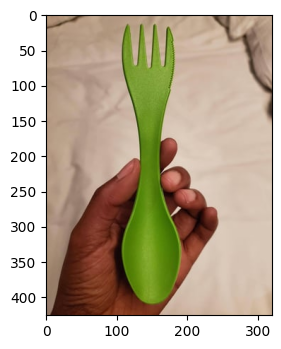

(320, 320)


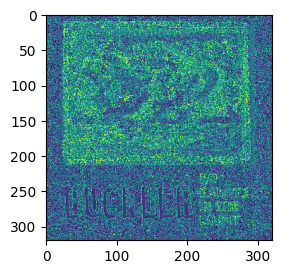

(216, 320, 3)


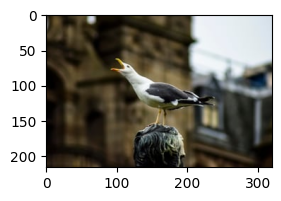

(266, 320)


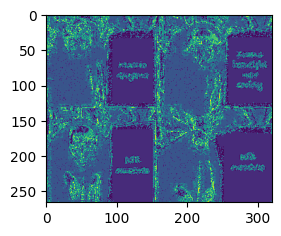

(180, 320, 3)


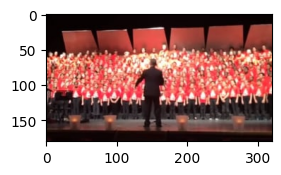

In [57]:
for i in range(5):
    path = "/kaggle/working/images/" + train_df["id"].iloc[i] + ".jpg"
    im = np.array(Image.open(path))
    print(im.shape)
    ax = plt.subplot(121)
    ax.imshow(im)
    plt.show()

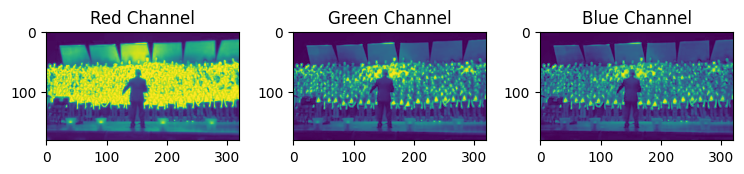

In [58]:
image_path = "/kaggle/working/images/" + train_df["id"].iloc[i] + ".jpg"
image = Image.open(image_path).convert("RGB")
r, g, b = image.split()
plt.figure(figsize=(10, 5))
plt.subplot(1, 4, 1)
plt.imshow(r)
plt.title('Red Channel')
plt.subplot(1, 4, 2)
plt.imshow(g)
plt.title('Green Channel')
plt.subplot(1, 4, 3)
plt.imshow(b)
plt.title('Blue Channel')
plt.tight_layout()
plt.show()

> **Dataset Creation**

In [59]:
class MultimodalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, transform=None):
        self.df = dataframe
        self.tokenizer = tokenizer
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row['clean_title']
        label = int(row['2_way_label'])
        image_path = f"/kaggle/working/images/{row['id']}.jpg"
        encoded = self.tokenizer(text, padding='max_length', truncation=True, max_length=32, return_tensors='pt')
        input_ids = encoded['input_ids'].squeeze(0)
        attention_mask = encoded['attention_mask'].squeeze(0)
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return input_ids, attention_mask, image, label

In [60]:
# Transform
import torchvision.transforms.v2 as v2
from torchvision import transforms

# Heavily augmented transform for training 
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224), 
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [61]:
# Transform for testing/validation 
test_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [62]:
# Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [63]:
# Dataloaders
train_dataset = MultimodalDataset(train_df, tokenizer, transform=train_transform) 
test_dataset = MultimodalDataset(test_df, tokenizer, transform=test_transform)   
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

> **Model Definition**

In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision.models import resnet50, ResNet50_Weights
from transformers import BertModel
from torchvision import transforms

In [77]:
# BAFT Model
class BAFTModel(nn.Module):
    def __init__(self):
        super(BAFTModel, self).__init__()

        # Text Branch
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.text_proj = nn.Sequential(
            nn.Linear(768, 512),
            nn.LayerNorm(512)
        )

        # Image Branch
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
        self.resnet = nn.Sequential(*list(resnet.children())[:-1])  # remove fc
        self.image_proj = nn.Sequential(
            nn.Linear(2048, 512),
            nn.LayerNorm(512)
        )

        # Fusion Layers
        self.attn = nn.MultiheadAttention(embed_dim=512, num_heads=8, batch_first=True)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=512,
            nhead=8,
            batch_first=True,
            dropout=0.2,
            activation="gelu"
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)

        # Gating mechanism for text vs image importance
        self.gate = nn.Linear(512 * 2, 2)

        # Classifier
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.SiLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, input_ids, attention_mask, images):
            # Text
            text_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            
            # Mean Pooling (better than pooler_output)
            last_hidden = text_out.last_hidden_state  # [batch, seq_len, hidden]
            mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
            sum_hidden = torch.sum(last_hidden * mask_expanded, dim=1)
            sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
            text_feat = sum_hidden / sum_mask
            text_feat = self.text_proj(text_feat)
    
            # Image
            img_feat = self.resnet(images)
            img_feat = img_feat.view(img_feat.size(0), -1)
            img_feat = self.image_proj(img_feat)
    
            # Combine Features
            combined = torch.stack([text_feat, img_feat], dim=1)
            attn_output, _ = self.attn(combined, combined, combined)
            encoded = self.transformer_encoder(attn_output)
    
             # Gating
            concat_feats = torch.cat([text_feat, img_feat], dim=-1)
            gate_weights = torch.softmax(self.gate(concat_feats), dim=-1)
            fused = gate_weights[:, 0].unsqueeze(1) * encoded[:, 0, :] + \
                    gate_weights[:, 1].unsqueeze(1) * encoded[:, 1, :]
            
            # Classification
            out = self.fc(fused)
            return out

     #Training Setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = BAFTModel().to(device)
    
    # Label smoothing loss
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-3)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

> **Model Training**

In [78]:
num_epochs = 10 
for epoch in range(num_epochs): 
    model.train() 
    running_loss = 0 
    correct = 0 
    total = 0 
    for input_ids, attention_mask, images, labels in train_loader: 
        input_ids, attention_mask = input_ids.to(device), attention_mask.to(device) 
        images, labels = images.to(device), labels.to(device) 
        outputs = model(input_ids, attention_mask, images) 
        loss = criterion(outputs, labels) 
        optimizer.zero_grad() 
        loss.backward() 
        optimizer.step() 
        running_loss += loss.item() 
        _, predicted = outputs.max(1) 
        total += labels.size(0) 
        correct += predicted.eq(labels).sum().item() 
    scheduler.step() 
    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader):.4f} Accuracy: {100.*correct/total:.2f}%")

Epoch 1 Loss: 0.4027 Accuracy: 87.74%
Epoch 2 Loss: 0.3170 Accuracy: 93.50%
Epoch 3 Loss: 0.2671 Accuracy: 96.56%
Epoch 4 Loss: 0.2423 Accuracy: 97.86%
Epoch 5 Loss: 0.2278 Accuracy: 98.72%
Epoch 6 Loss: 0.2216 Accuracy: 99.11%
Epoch 7 Loss: 0.2158 Accuracy: 99.39%
Epoch 8 Loss: 0.2118 Accuracy: 99.61%
Epoch 9 Loss: 0.2103 Accuracy: 99.65%
Epoch 10 Loss: 0.2094 Accuracy: 99.74%


>**Model Evaluation**

In [79]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for input_ids, att_mask, images, labels in test_loader:
        input_ids, att_mask = input_ids.to(device), att_mask.to(device)
        images, labels = images.to(device), labels.to(device)
        outputs = model(input_ids, att_mask, images)
        _, predicted = outputs.max(1)
        y_true.extend(labels.cpu().numpy()); y_pred.extend(predicted.cpu().numpy())

In [80]:
print(classification_report(y_true, y_pred, digits=4, target_names=["Fake", "Real"]))

              precision    recall  f1-score   support

        Fake     0.8363    0.7974    0.8164      3465
        Real     0.8435    0.8749    0.8589      4325

    accuracy                         0.8404      7790
   macro avg     0.8399    0.8362    0.8376      7790
weighted avg     0.8403    0.8404    0.8400      7790



>**Evaluation Metrics**

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

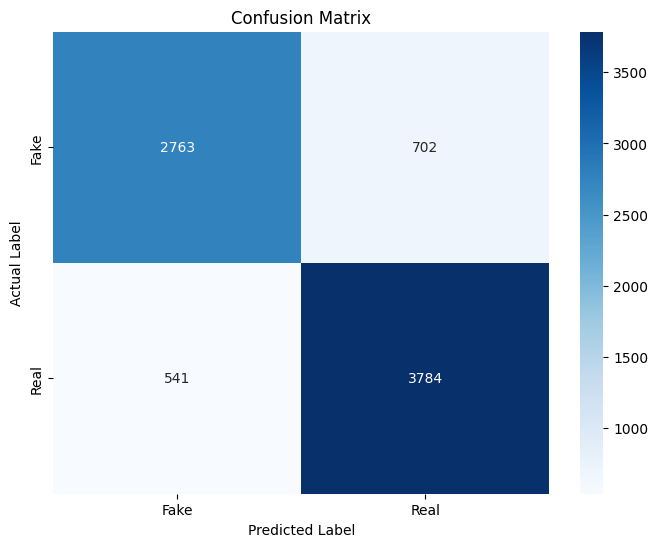

In [82]:
# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Fake", "Real"], 
            yticklabels=["Fake", "Real"])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [83]:
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc

model.eval()
y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for input_ids, att_mask, images, labels in test_loader:
        input_ids, att_mask = input_ids.to(device), att_mask.to(device)
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(input_ids, att_mask, images)
        _, predicted = outputs.max(1)
        
        # Get probabilities for the positive class (assuming class 1 is "Real")
        probabilities = F.softmax(outputs, dim=1)[:, 1] 
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_probs.extend(probabilities.cpu().numpy())

Palette images with Transparency expressed in bytes should be converted to RGBA images


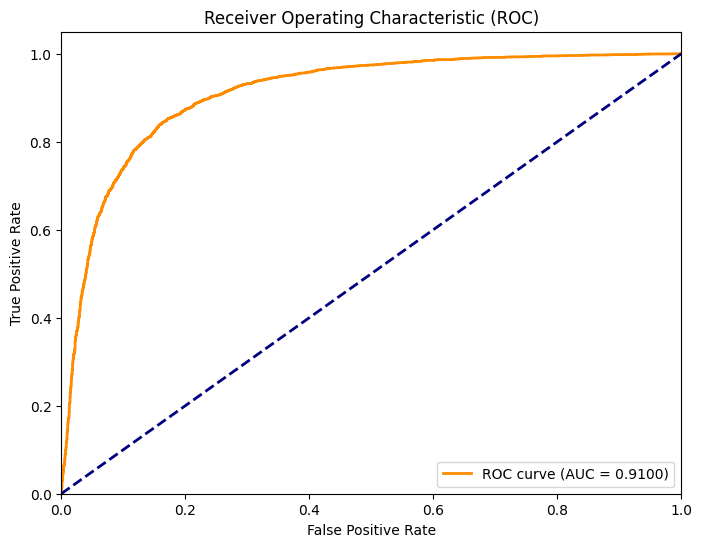

In [84]:
# Calculate False Positive Rate, True Positive Rate, and Area Under Curve
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

>**Explainable AI**

In [85]:
!pip install grad-cam

In [86]:
%matplotlib inline
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [87]:
# Create a wrapper to isolate the image input
class ImageModelWrapper(torch.nn.Module):
    def __init__(self, model, input_ids, attention_mask):
        super(ImageModelWrapper, self).__init__()
        self.model = model
        self.input_ids = input_ids
        self.attention_mask = attention_mask

    def forward(self, images):
        # Pass the frozen text inputs along with the varying images
        return self.model(self.input_ids, self.attention_mask, images)

In [88]:
def apply_gradcam(model, input_ids, attention_mask, image_tensor, original_rgb_image):
    model.eval()
    
    # Wrap the model
    wrapped_model = ImageModelWrapper(model, input_ids, attention_mask)
    
    # Target the last convolutional layer in your ResNet branch
    target_layers = [model.resnet[-2][-1]] 
    
    # Initialize GradCAM
    cam = GradCAM(model=wrapped_model, target_layers=target_layers)
    
    # Generate the heatmap
    targets = None # None defaults to the highest scoring class
    grayscale_cam = cam(input_tensor=image_tensor, targets=targets)[0, :]
    
    # Overlay the heatmap on the original image
    visualization = show_cam_on_image(original_rgb_image, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Original Image
    axes[0].imshow(original_rgb_image)
    axes[0].set_title("Original Image", fontsize=14)
    axes[0].axis('off')

    # Raw Heatmap
    # Using the 'jet' colormap to make the high/low focus areas pop
    heatmap_plot = axes[1].imshow(grayscale_cam, cmap='jet')
    axes[1].set_title("Raw Grad-CAM Heatmap", fontsize=14)
    axes[1].axis('off')
    
    # Overlayed Image
    axes[2].imshow(visualization)
    axes[2].set_title("Overlayed Image", fontsize=14)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

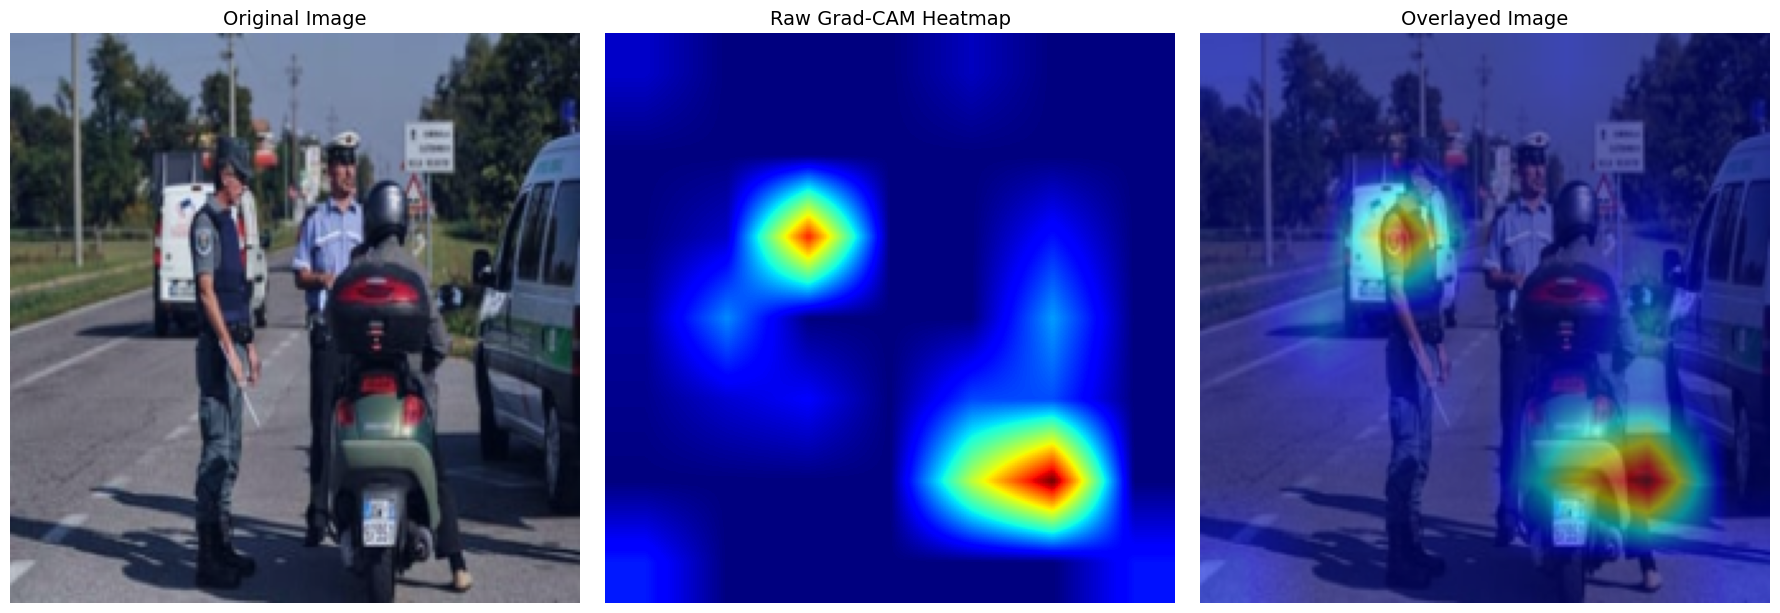

In [89]:
try:
    input_ids_batch, attention_mask_batch, images_batch, labels_batch = next(iter(test_loader))

    # Isolate the very first item in that batch (keeping the batch dimension of 1)
    sample_ids = input_ids_batch[0:1].to(device)
    sample_mask = attention_mask_batch[0:1].to(device)
    sample_img = images_batch[0:1].to(device)

    # Convert the PyTorch image tensor back to a format Grad-CAM can plot
    # Move to CPU, remove the batch dimension, and rearrange from (C, H, W) to (H, W, C)
    orig_image_np = sample_img.squeeze().cpu().numpy().transpose(1, 2, 0)

    # Normalize the image array so all pixel values are between 0 and 1
    # This prevents the image from rendering as a solid black square
    orig_image_np = (orig_image_np - orig_image_np.min()) / (orig_image_np.max() - orig_image_np.min())

    # Actually call the function to generate the plot!
    apply_gradcam(model, sample_ids, sample_mask, sample_img, orig_image_np)

except NameError as e:
    print(f"Hold up! {e}")
    print("Make sure 'test_loader', 'device', and 'model' are defined in the cells above this one.")

In [90]:
import shap
import numpy as np
import torch

# Create a wrapper to isolate the text input
class TextModelWrapper(torch.nn.Module):
    def __init__(self, model, images):
        super(TextModelWrapper, self).__init__()
        self.model = model
        self.images = images

    def forward(self, input_ids, attention_mask):
        # Find out how many text variations SHAP is testing in this batch
        batch_size = input_ids.size(0)
        
        # Expand the single image to match the text batch size
        # If SHAP sends 2 texts, we give the model 2 identical images!
        expanded_images = self.images.expand(batch_size, -1, -1, -1)
        
        return self.model(input_ids.long(), attention_mask.long(), expanded_images)

In [91]:
def apply_shap_text(model, tokenizer, text_list, image_tensor):
    model.eval()
    
    wrapped_model = TextModelWrapper(model, image_tensor).to(device)
    
    def predict_fn(texts):
        if isinstance(texts, np.ndarray):
            texts = texts.tolist()
        texts = [str(t) for t in texts] 
        
        inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = wrapped_model(inputs['input_ids'], inputs['attention_mask'])
            return torch.softmax(outputs, dim=1).cpu().numpy()

    explainer = shap.Explainer(predict_fn, tokenizer)
    
    print("Calculating SHAP values (this may take a minute)...")
    shap_values = explainer(text_list)
    
    return shap.plots.text(shap_values[0])

shap.initjs()

In [92]:
try:
    input_ids_batch, attention_mask_batch, images_batch, labels_batch = next(iter(test_loader))

    sample_ids = input_ids_batch[0]
    sample_img = images_batch[0:1].to(device) 

    sample_text = tokenizer.decode(sample_ids, skip_special_tokens=True)
    
    print(f"Analyzing Text: {sample_text}")

    # Display the interactive plot
    apply_shap_text(model, tokenizer, [sample_text], sample_img)

except NameError as e:
    print(f"Hold up! {e}")

Analyzing Text: italian court bribe from drunk driver not enough to be corrupt
Calculating SHAP values (this may take a minute)...
